# Satellite vs Satellite AOD Inter-Comparison
## Publication-Quality Analysis: MODIS, VIIRS, and Himawari AOD at 550 nm

**Objective:** Rigorously inter-compare Aerosol Optical Depth (AOD) retrievals from three satellite sensors over Vietnam (2022–2026), following standard practices from NASA validation literature.

**Sensors:**
- **MODIS** (MCD19A2 MAIAC): AOD at 550 nm, polar orbit (~10:30 & 13:30 LT)
- **VIIRS** (NOAA-20): AOD at 550 nm, polar orbit (~13:30 LT)
- **Himawari-8/9** (AHI): AOD at 500 nm (corrected to 550 nm), geostationary (hourly)

**Methodology:**
1. Temporal collocation via nearest-time matching with configurable tolerance
2. Spectral harmonization (Himawari 500→550 nm via Ångström exponent)
3. Pairwise scatter analysis with density (hexbin) plots
4. Regional stratification: North / Central / South Vietnam
5. Seasonal decomposition (DJF, MAM, JJA, SON)

**Stations:** 27 EnviSoft air quality monitoring stations across Vietnam

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy import stats
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.figsize': (8, 7),
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
})

print('Imports OK')

Imports OK


In [33]:
# === Paths ===
STATIONS_PATH = '/home/work1/projects/Air_Quality/Masterdata/envisoft_27_stations.csv'
MODIS_DIR = '/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v3/'
HIMAWARI_L3_DIR = '/home/slow_data/Air_Quality/Himawari/station_aod_v3/L3/'
VIIRS_L2_PATH = '/home/slow_data/Air_Quality/VIIRS/output/viirs_aod_L2_NOAA20_nearest_filtered.csv'
VIIRS_L3_PATH = '/home/slow_data/Air_Quality/VIIRS/output/viirs_aod_D3_NOAA20.csv'

# === Parameters ===
TIME_TOLERANCE = '1h'           # collocation time window (±1 hour)
AOD_MAX = 5.0                   # upper bound for valid AOD
AOD_MIN = -0.05                 # lower bound (slightly negative allowed per MODIS convention)
HIMAWARI_WAVELENGTH = 500       # nm
TARGET_WAVELENGTH = 550         # nm

# === Regional thresholds (latitude-based) ===
LAT_NORTH = 17.5
LAT_CENTRAL = 11.0

print(f'Time tolerance: {TIME_TOLERANCE}')
print(f'AOD range: [{AOD_MIN}, {AOD_MAX}]')

Time tolerance: 1h
AOD range: [-0.05, 5.0]


In [34]:
def classify_region(lat):
    if lat >= LAT_NORTH:
        return 'North'
    elif lat >= LAT_CENTRAL:
        return 'Central'
    return 'South'

def get_season(month):
    return {12: 'DJF', 1: 'DJF', 2: 'DJF',
            3: 'MAM', 4: 'MAM', 5: 'MAM',
            6: 'JJA', 7: 'JJA', 8: 'JJA',
            9: 'SON', 10: 'SON', 11: 'SON'}[month]

def compute_metrics(x, y):
    """Compute validation metrics between reference (x) and target (y)."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = np.asarray(x)[mask], np.asarray(y)[mask]
    n = len(x)
    if n < 5:
        return None
    slope, intercept, r, p, se = stats.linregress(x, y)
    diff = y - x
    rmse = np.sqrt(np.mean(diff**2))
    mae = np.mean(np.abs(diff))
    bias = np.mean(diff)
    rel_bias = 100 * bias / np.mean(x) if np.mean(x) != 0 else np.nan
    ee = 0.05 + 0.15 * np.abs(x)
    pct_ee = 100 * np.sum(np.abs(diff) <= ee) / n
    return {'N': n, 'R': round(r, 4), 'R2': round(r**2, 4),
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'Bias': round(bias, 4), 'RelBias%': round(rel_bias, 2),
            'Slope': round(slope, 4), 'Intercept': round(intercept, 4),
            '%EE': round(pct_ee, 1)}

def validation_scatter(x, y, xlabel, ylabel, title, ax=None, hexbin=True):
    """Publication-quality scatter plot with density coloring and metrics."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    m = compute_metrics(x, y)
    if m is None:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes, ha='center')
        return None

    mask = np.isfinite(x) & np.isfinite(y)
    xv, yv = np.asarray(x)[mask], np.asarray(y)[mask]

    if hexbin and len(xv) > 50:
        hb = ax.hexbin(xv, yv, gridsize=35, mincnt=1, cmap='YlOrRd', linewidths=0.2)
        plt.colorbar(hb, ax=ax, label='Count', shrink=0.8)
    else:
        ax.scatter(xv, yv, s=15, alpha=0.5, edgecolors='none', c='steelblue')

    vmax = max(np.percentile(xv, 99), np.percentile(yv, 99)) * 1.15
    vmin = max(0, min(xv.min(), yv.min()) - 0.02)
    lims = [vmin, vmax]
    ax.plot(lims, lims, 'k--', lw=1, label='1:1', zorder=5)
    xfit = np.array(lims)
    ax.plot(xfit, m['Slope'] * xfit + m['Intercept'], 'b-', lw=1.5, zorder=5,
            label=f"y = {m['Slope']:.3f}x + {m['Intercept']:.3f}")

    txt = (f"N = {m['N']}\n"
           f"R\u00b2 = {m['R2']:.3f}\n"
           f"RMSE = {m['RMSE']:.3f}\n"
           f"MAE = {m['MAE']:.3f}\n"
           f"Bias = {m['Bias']:.4f}\n"
           f"%EE = {m['%EE']:.1f}%")
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.4'))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    return m

print('Helper functions defined')

Helper functions defined


---
## 1. Data Loading

Load AOD data from three satellite platforms and the 27 EnviSoft monitoring stations.

In [35]:
stations = pd.read_csv(STATIONS_PATH)
stations['stationId'] = stations['stationId'].astype(str)
stations['region'] = stations['latitude'].apply(classify_region)
target_ids = set(stations['stationId'])
station_id_to_name = dict(zip(stations['stationId'], stations['stationName']))
station_name_to_region = dict(zip(stations['stationName'], stations['region']))
station_name_to_lat = dict(zip(stations['stationName'], stations['latitude']))
station_name_to_lon = dict(zip(stations['stationName'], stations['longitude']))

print(f'Loaded {len(stations)} target stations')
print(f'Regional distribution: {stations["region"].value_counts().to_dict()}')
stations[['stationName', 'latitude', 'longitude', 'region']].head(10)

Loaded 27 target stations
Regional distribution: {'North': 10, 'Central': 9, 'South': 8}


,stationName,latitude,longitude,region
0,Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK),21.3385,105.367,North
1,Bình Định: Khuôn viên Cây xanh gần cầu chui đư...,13.7851,109.220,Central
2,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",10.9923,106.658,South
3,Đà Nẵng: Khuôn viên trường ĐH sư phạm Đà Nẵng ...,16.0622,108.159,Central
4,Hà Nam: Công Viên Nam Cao - P.Quang Trung - TP...,20.5360,105.916,North
5,Hà Nội: ĐHBK cổng Parabol đường Giải Phóng (KK),21.0052,105.842,North
6,Hà Nội: Công viên Nhân Chính - Khuất Duy Tiến ...,21.0031,105.795,North
7,HCM: Khu Liên cơ quan Bộ Tài Nguyên và Môi Trư...,10.7823,106.683,South
8,HCM: Đ. Lê Hữu Kiều - P. Bình Trưng Tây - Quận...,10.7832,106.753,South
9,Hưng Yên: số 437 Nguyễn Văn Linh - Tp Hưng Yên...,20.6618,106.059,North


In [36]:
modis_files = glob.glob(MODIS_DIR + '*.csv')
modis_dfs = []
for f in modis_files:
    try:
        df = pd.read_csv(f, parse_dates=['timestamp'], low_memory=False)
        df['stationId'] = df['stationId'].astype(str)
        if df['stationId'].iloc[0] in target_ids:
            modis_dfs.append(df)
    except Exception as e:
        pass

modis_raw = pd.concat(modis_dfs, ignore_index=True)
modis_raw['station_name'] = modis_raw['stationId'].map(station_id_to_name)

# QA filtering: keep valid AOD
modis = modis_raw[
    (modis_raw['Optical_Depth_055'].notna()) &
    (modis_raw['Optical_Depth_055'] >= AOD_MIN) &
    (modis_raw['Optical_Depth_055'] <= AOD_MAX)
].copy()
modis = modis.rename(columns={'timestamp': 'datetime', 'Optical_Depth_055': 'aod_550'})
modis['region'] = modis['station_name'].map(station_name_to_region)

print(f'MODIS: {len(modis_raw)} raw -> {len(modis)} QA-filtered records')
print(f'Stations: {modis["station_name"].nunique()}')
print(f'Date range: {modis["datetime"].min()} to {modis["datetime"].max()}')

MODIS: 19209 raw -> 19209 QA-filtered records
Stations: 27
Date range: 2022-09-01 10:55:00 to 2026-03-10 15:40:00


In [37]:
hima_files = glob.glob(HIMAWARI_L3_DIR + '*.csv')
hima_dfs = []
for f in hima_files:
    try:
        df = pd.read_csv(f, parse_dates=['timestamp'], low_memory=False)
        df['stationId'] = df['stationId'].astype(str)
        if df['stationId'].iloc[0] in target_ids:
            hima_dfs.append(df)
    except Exception as e:
        pass

hima_raw = pd.concat(hima_dfs, ignore_index=True)
hima_raw['station_name'] = hima_raw['stationId'].map(station_id_to_name)

# QA filtering
hima = hima_raw[
    (hima_raw['AOT_Merged_center'].notna()) &
    (hima_raw['AOT_Merged_center'] > AOD_MIN) &
    (hima_raw['AOT_Merged_center'] <= AOD_MAX)
].copy()

# Spectral correction: 500 nm -> 550 nm using Angstrom exponent
ae = hima['AE_Merged']
valid_ae = ae.notna() & (ae > 0) & (ae < 3)
hima['aod_550'] = np.where(
    valid_ae,
    hima['AOT_Merged_center'] * (TARGET_WAVELENGTH / HIMAWARI_WAVELENGTH) ** (-ae),
    hima['AOT_Merged_center']  # fallback: use 500nm directly
)
hima['ae_corrected'] = valid_ae
hima = hima.rename(columns={'timestamp': 'datetime'})
hima['region'] = hima['station_name'].map(station_name_to_region)

pct_corrected = 100 * valid_ae.sum() / len(hima)
print(f'Himawari L3: {len(hima_raw)} raw -> {len(hima)} QA-filtered records')
print(f'Stations: {hima["station_name"].nunique()}')
print(f'AE correction applied: {pct_corrected:.1f}% of records')
print(f'Date range: {hima["datetime"].min()} to {hima["datetime"].max()}')

Himawari L3: 30092 raw -> 14171 QA-filtered records
Stations: 27
AE correction applied: 5.5% of records
Date range: 2022-09-01 08:00:00 to 2026-04-16 17:00:00


In [38]:
viirs_l2 = pd.read_csv(VIIRS_L2_PATH, parse_dates=['datetime'])
viirs_l2 = viirs_l2.rename(columns={'station': 'station_name', 'aod': 'aod_550'})

# QA filtering
viirs_l2 = viirs_l2[
    (viirs_l2['aod_550'].notna()) &
    (viirs_l2['aod_550'] >= AOD_MIN) &
    (viirs_l2['aod_550'] <= AOD_MAX) &
    (viirs_l2['qa'] >= viirs_l2['qa_threshold'])
].copy()
viirs_l2['region'] = viirs_l2['station_name'].map(station_name_to_region)

# Also load L3 for later comparison
viirs_l3 = pd.read_csv(VIIRS_L3_PATH, parse_dates=['datetime'])
viirs_l3 = viirs_l3.rename(columns={'station': 'station_name', 'aod_mean': 'aod_550'})
viirs_l3 = viirs_l3[
    (viirs_l3['aod_550'].notna()) &
    (viirs_l3['aod_550'] >= AOD_MIN) &
    (viirs_l3['aod_550'] <= AOD_MAX)
].copy()
viirs_l3['region'] = viirs_l3['station_name'].map(station_name_to_region)

print(f'VIIRS L2: {len(viirs_l2)} QA-filtered records, {viirs_l2["station_name"].nunique()} stations')
print(f'VIIRS L3: {len(viirs_l3)} records, {viirs_l3["station_name"].nunique()} stations')
print(f'L2 date range: {viirs_l2["datetime"].min()} to {viirs_l2["datetime"].max()}')

VIIRS L2: 2096 QA-filtered records, 25 stations
VIIRS L3: 16880 records, 27 stations
L2 date range: 2022-01-01 12:54:00 to 2026-04-21 13:18:00


---
## 2. Data Summary & Preprocessing

Overview of the three datasets after quality filtering.

In [39]:
summary_data = []
for name, df in [('MODIS (550 nm)', modis), ('Himawari (550 nm, corrected)', hima),
                  ('VIIRS L2 (550 nm)', viirs_l2), ('VIIRS L3 (550 nm)', viirs_l3)]:
    summary_data.append({
        'Dataset': name,
        'Records': len(df),
        'Stations': df['station_name'].nunique(),
        'Date range': f"{df['datetime'].min().strftime('%Y-%m-%d')} to {df['datetime'].max().strftime('%Y-%m-%d')}",
        'AOD mean': round(df['aod_550'].mean(), 3),
        'AOD median': round(df['aod_550'].median(), 3),
        'AOD std': round(df['aod_550'].std(), 3),
        'AOD P95': round(df['aod_550'].quantile(0.95), 3),
    })

pd.DataFrame(summary_data)

,Dataset,Records,Stations,Date range,AOD mean,AOD median,AOD std,AOD P95
0,MODIS (550 nm),19209,27,2022-09-01 to 2026-03-10,0.303,0.268,0.222,0.678
1,"Himawari (550 nm, corrected)",14171,27,2022-09-01 to 2026-04-16,0.390,0.316,0.286,0.958
2,VIIRS L2 (550 nm),2096,25,2022-01-01 to 2026-04-21,0.514,0.365,0.490,1.484
3,VIIRS L3 (550 nm),16880,27,2021-12-31 to 2026-04-18,0.356,0.268,0.316,0.928


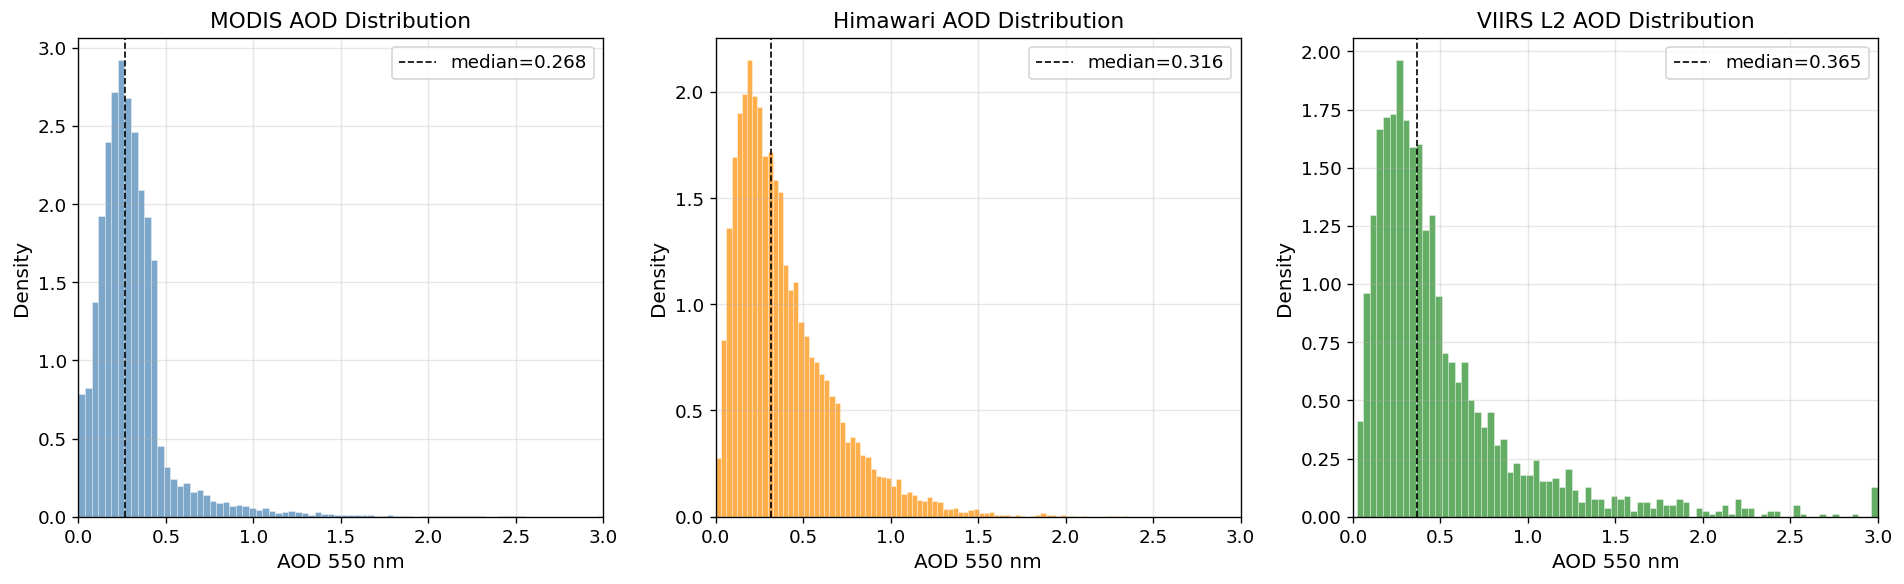

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, df, color) in zip(axes, [
    ('MODIS', modis, 'steelblue'),
    ('Himawari', hima, 'darkorange'),
    ('VIIRS L2', viirs_l2, 'forestgreen')
]):
    ax.hist(df['aod_550'].clip(0, 3), bins=80, color=color, alpha=0.7, density=True, edgecolor='white', linewidth=0.3)
    ax.axvline(df['aod_550'].median(), color='k', ls='--', lw=1, label=f"median={df['aod_550'].median():.3f}")
    ax.set_xlabel('AOD 550 nm')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} AOD Distribution')
    ax.set_xlim(0, 3)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Temporal Collocation

**Strategy:** For each pair of sensors, we use `merge_asof` with nearest-time matching within the configured tolerance window. The reference sensor (typically with fewer observations) drives the matching.

**Time tolerance:** ±1 hour (configurable; sensitivity analysis follows in Section 8)

For each pair, the sensor with fewer overpasses acts as the reference:
- **MODIS vs Himawari:** MODIS as reference (polar → geostationary)
- **MODIS vs VIIRS:** MODIS as reference (similar orbits)
- **VIIRS vs Himawari:** VIIRS as reference (polar → geostationary)

In [41]:
def collocate(df_ref, df_target, name_ref, name_target, tolerance=TIME_TOLERANCE):
    """Temporally collocate two datasets per station using nearest-time matching."""
    cols_ref = ['station_name', 'datetime', 'aod_550', 'region']
    cols_tgt = ['station_name', 'datetime', 'aod_550']

    d1 = df_ref[cols_ref].dropna(subset=['aod_550']).copy()
    d2 = df_target[cols_tgt].dropna(subset=['aod_550']).copy()

    d1 = d1.rename(columns={'aod_550': f'AOD_{name_ref}'})
    d2 = d2.rename(columns={'aod_550': f'AOD_{name_target}'})

    # Merge per station to avoid global sort requirement of merge_asof
    common_stations = set(d1['station_name'].unique()) & set(d2['station_name'].unique())
    parts = []
    for stn in common_stations:
        s1 = d1[d1['station_name'] == stn].sort_values('datetime').reset_index(drop=True)
        s2 = d2[d2['station_name'] == stn].sort_values('datetime').reset_index(drop=True)
        if len(s1) == 0 or len(s2) == 0:
            continue
        merged = pd.merge_asof(
            s1, s2[['datetime', f'AOD_{name_target}']],
            on='datetime', tolerance=pd.Timedelta(tolerance), direction='nearest'
        )
        merged = merged.dropna(subset=[f'AOD_{name_target}'])
        if len(merged) > 0:
            parts.append(merged)

    result = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    print(f'{name_ref} vs {name_target}: {len(d1)} ref obs -> {len(result)} matched pairs '
          f'({100*len(result)/max(len(d1),1):.1f}% match rate, {len(common_stations)} stations)')
    return result

# Run all pairwise collocations
print(f'=== Collocation with tolerance = {TIME_TOLERANCE} ===\n')
pair_modis_hima = collocate(modis, hima, 'MODIS', 'Himawari')
pair_modis_viirs = collocate(modis, viirs_l2, 'MODIS', 'VIIRS')
pair_viirs_hima = collocate(viirs_l2, hima, 'VIIRS', 'Himawari')

=== Collocation with tolerance = 1h ===

MODIS vs Himawari: 19209 ref obs -> 3047 matched pairs (15.9% match rate, 27 stations)
MODIS vs VIIRS: 19209 ref obs -> 788 matched pairs (4.1% match rate, 25 stations)
VIIRS vs Himawari: 2096 ref obs -> 913 matched pairs (43.6% match rate, 25 stations)


---
## 4. Pairwise Comparison: MODIS vs Himawari

MODIS MCD19A2 (MAIAC) AOD at 550 nm versus Himawari AHI AOD corrected from 500 nm to 550 nm using the Ångström exponent.

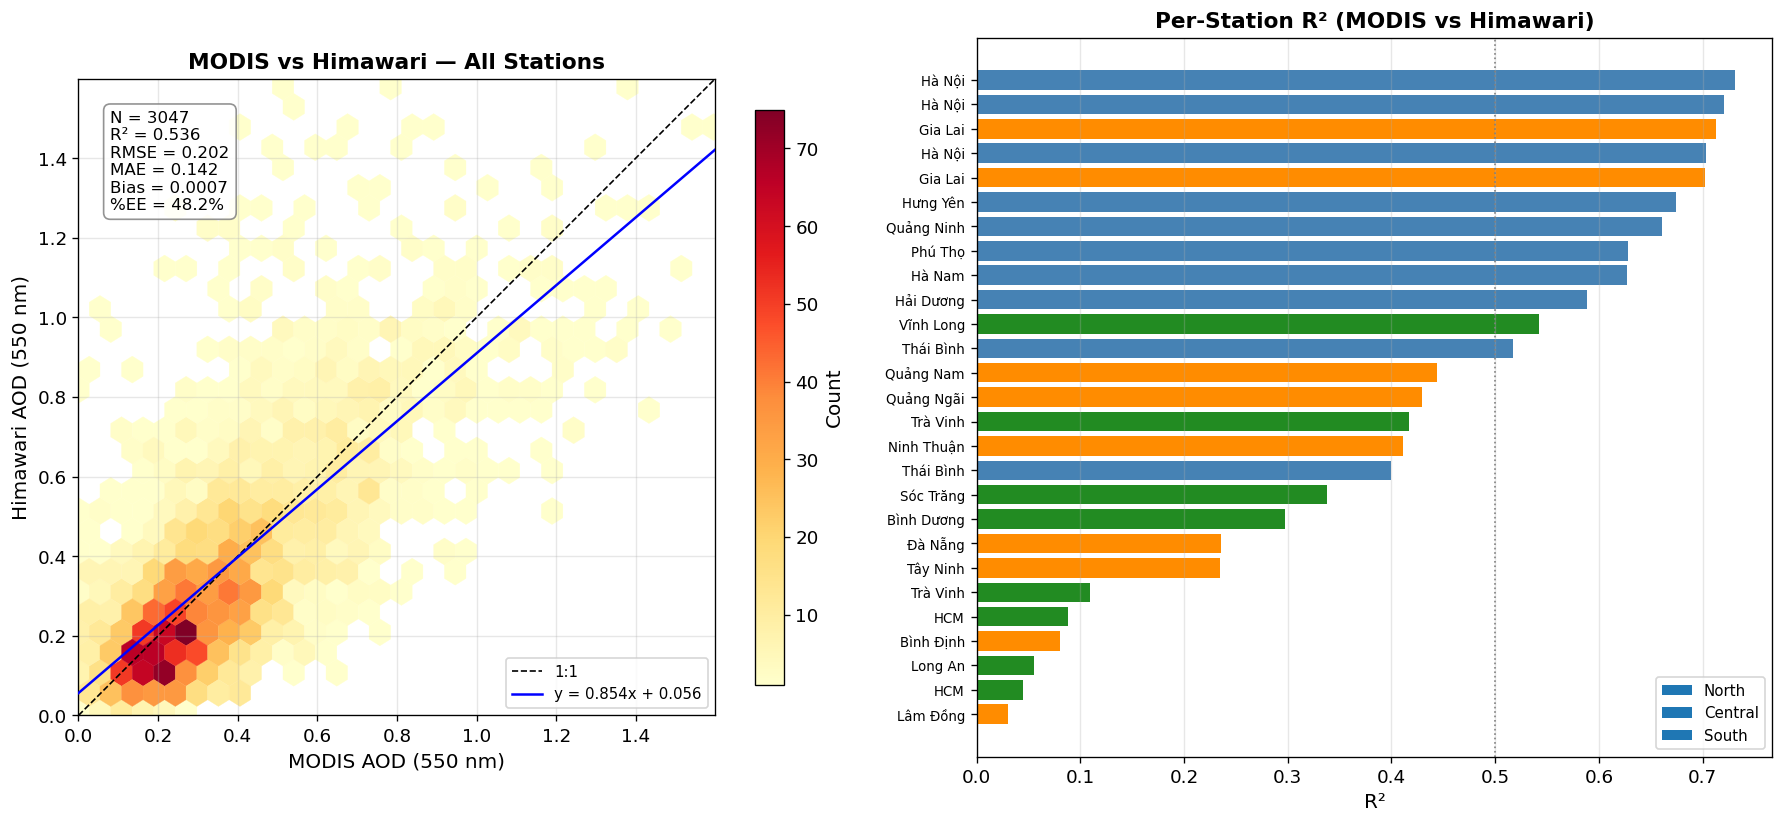


Global metrics:


N            3047.0000
R               0.7320
R2              0.5358
RMSE            0.2015
MAE             0.1417
Bias            0.0007
RelBias%        0.1800
Slope           0.8535
Intercept       0.0563
%EE            48.2000
dtype: float64

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

m_global = validation_scatter(
    pair_modis_hima['AOD_MODIS'], pair_modis_hima['AOD_Himawari'],
    'MODIS AOD (550 nm)', 'Himawari AOD (550 nm)',
    'MODIS vs Himawari — All Stations', ax=axes[0]
)

# Per-station metrics
station_metrics_mh = []
for stn in pair_modis_hima['station_name'].unique():
    sub = pair_modis_hima[pair_modis_hima['station_name'] == stn]
    m = compute_metrics(sub['AOD_MODIS'], sub['AOD_Himawari'])
    if m:
        m['station'] = stn
        m['region'] = sub['region'].iloc[0]
        station_metrics_mh.append(m)

df_stn_mh = pd.DataFrame(station_metrics_mh).sort_values('R2', ascending=False)

# Bar chart of R2 by station
colors = {'North': 'steelblue', 'Central': 'darkorange', 'South': 'forestgreen'}
bar_colors = [colors[r] for r in df_stn_mh['region']]
axes[1].barh(range(len(df_stn_mh)), df_stn_mh['R2'], color=bar_colors)
axes[1].set_yticks(range(len(df_stn_mh)))
axes[1].set_yticklabels([s.split(':')[0] for s in df_stn_mh['station']], fontsize=8)
axes[1].set_xlabel('R\u00b2')
axes[1].set_title('Per-Station R\u00b2 (MODIS vs Himawari)', fontweight='bold')
axes[1].axvline(0.5, color='gray', ls=':', lw=1)
for region, c in colors.items():
    axes[1].barh([], [], color=c, label=region)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\nGlobal metrics:')
pd.Series(m_global)

---
## 5. Pairwise Comparison: MODIS vs VIIRS

Both sensors observe at 550 nm from polar orbits. MODIS (Terra/Aqua) and VIIRS (NOAA-20) have near-simultaneous overpasses (~13:30 LT for Aqua and NOAA-20).

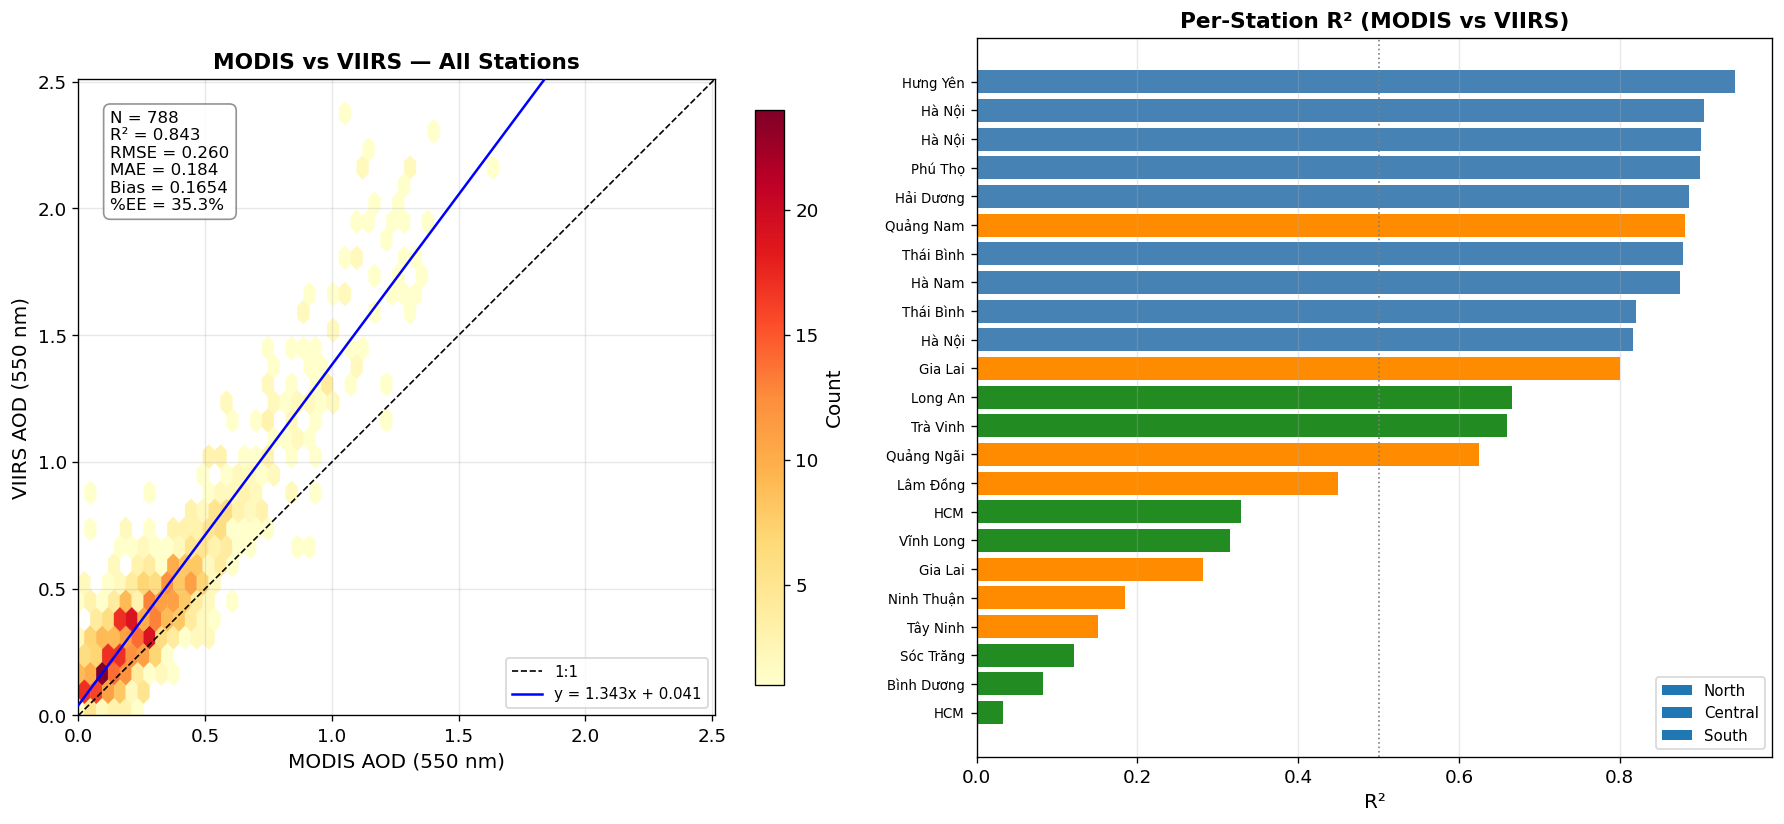


Global metrics:


N            788.0000
R              0.9181
R2             0.8430
RMSE           0.2599
MAE            0.1845
Bias           0.1654
RelBias%      45.6000
Slope          1.3428
Intercept      0.0410
%EE           35.3000
dtype: float64

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

m_global_mv = validation_scatter(
    pair_modis_viirs['AOD_MODIS'], pair_modis_viirs['AOD_VIIRS'],
    'MODIS AOD (550 nm)', 'VIIRS AOD (550 nm)',
    'MODIS vs VIIRS — All Stations', ax=axes[0]
)

station_metrics_mv = []
for stn in pair_modis_viirs['station_name'].unique():
    sub = pair_modis_viirs[pair_modis_viirs['station_name'] == stn]
    m = compute_metrics(sub['AOD_MODIS'], sub['AOD_VIIRS'])
    if m:
        m['station'] = stn
        m['region'] = sub['region'].iloc[0]
        station_metrics_mv.append(m)

df_stn_mv = pd.DataFrame(station_metrics_mv).sort_values('R2', ascending=False)

colors = {'North': 'steelblue', 'Central': 'darkorange', 'South': 'forestgreen'}
bar_colors = [colors[r] for r in df_stn_mv['region']]
axes[1].barh(range(len(df_stn_mv)), df_stn_mv['R2'], color=bar_colors)
axes[1].set_yticks(range(len(df_stn_mv)))
axes[1].set_yticklabels([s.split(':')[0] for s in df_stn_mv['station']], fontsize=8)
axes[1].set_xlabel('R\u00b2')
axes[1].set_title('Per-Station R\u00b2 (MODIS vs VIIRS)', fontweight='bold')
axes[1].axvline(0.5, color='gray', ls=':', lw=1)
for region, c in colors.items():
    axes[1].barh([], [], color=c, label=region)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\nGlobal metrics:')
pd.Series(m_global_mv)

---
## 6. Pairwise Comparison: VIIRS vs Himawari

VIIRS at 550 nm versus Himawari AHI (corrected to 550 nm). These sensors have fundamentally different orbits: polar vs geostationary.

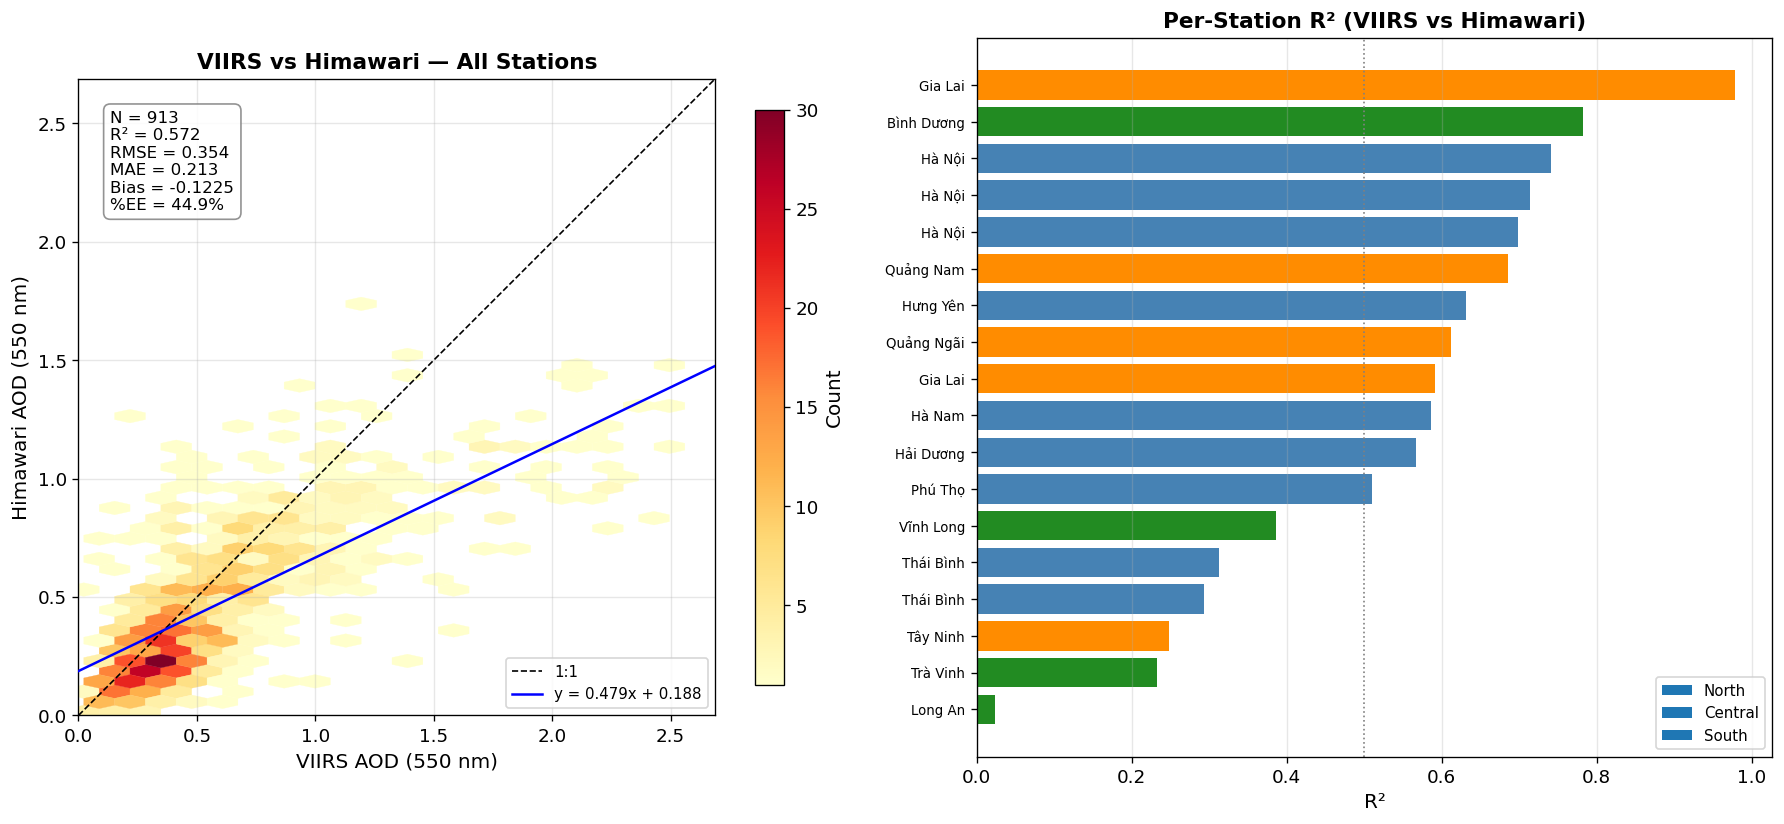


Global metrics:


N            913.0000
R              0.7560
R2             0.5715
RMSE           0.3545
MAE            0.2130
Bias          -0.1225
RelBias%     -20.5800
Slope          0.4792
Intercept      0.1875
%EE           44.9000
dtype: float64

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

m_global_vh = validation_scatter(
    pair_viirs_hima['AOD_VIIRS'], pair_viirs_hima['AOD_Himawari'],
    'VIIRS AOD (550 nm)', 'Himawari AOD (550 nm)',
    'VIIRS vs Himawari — All Stations', ax=axes[0]
)

station_metrics_vh = []
for stn in pair_viirs_hima['station_name'].unique():
    sub = pair_viirs_hima[pair_viirs_hima['station_name'] == stn]
    m = compute_metrics(sub['AOD_VIIRS'], sub['AOD_Himawari'])
    if m:
        m['station'] = stn
        m['region'] = sub['region'].iloc[0]
        station_metrics_vh.append(m)

df_stn_vh = pd.DataFrame(station_metrics_vh).sort_values('R2', ascending=False)

colors = {'North': 'steelblue', 'Central': 'darkorange', 'South': 'forestgreen'}
bar_colors = [colors[r] for r in df_stn_vh['region']]
axes[1].barh(range(len(df_stn_vh)), df_stn_vh['R2'], color=bar_colors)
axes[1].set_yticks(range(len(df_stn_vh)))
axes[1].set_yticklabels([s.split(':')[0] for s in df_stn_vh['station']], fontsize=8)
axes[1].set_xlabel('R\u00b2')
axes[1].set_title('Per-Station R\u00b2 (VIIRS vs Himawari)', fontweight='bold')
axes[1].axvline(0.5, color='gray', ls=':', lw=1)
for region, c in colors.items():
    axes[1].barh([], [], color=c, label=region)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('\nGlobal metrics:')
pd.Series(m_global_vh)

---
## 7. Regional Analysis

Compare AOD agreement across three geographic regions of Vietnam:
- **North** (≥17.5°N): Red River Delta, includes Hanoi — higher aerosol loading, continental influence
- **Central** (11.0–17.5°N): Coastal and highland stations — complex terrain, biomass burning
- **South** (<11.0°N): Mekong Delta and HCMC — tropical, lower AOD baseline

=== MODIS vs Himawari by Region ===


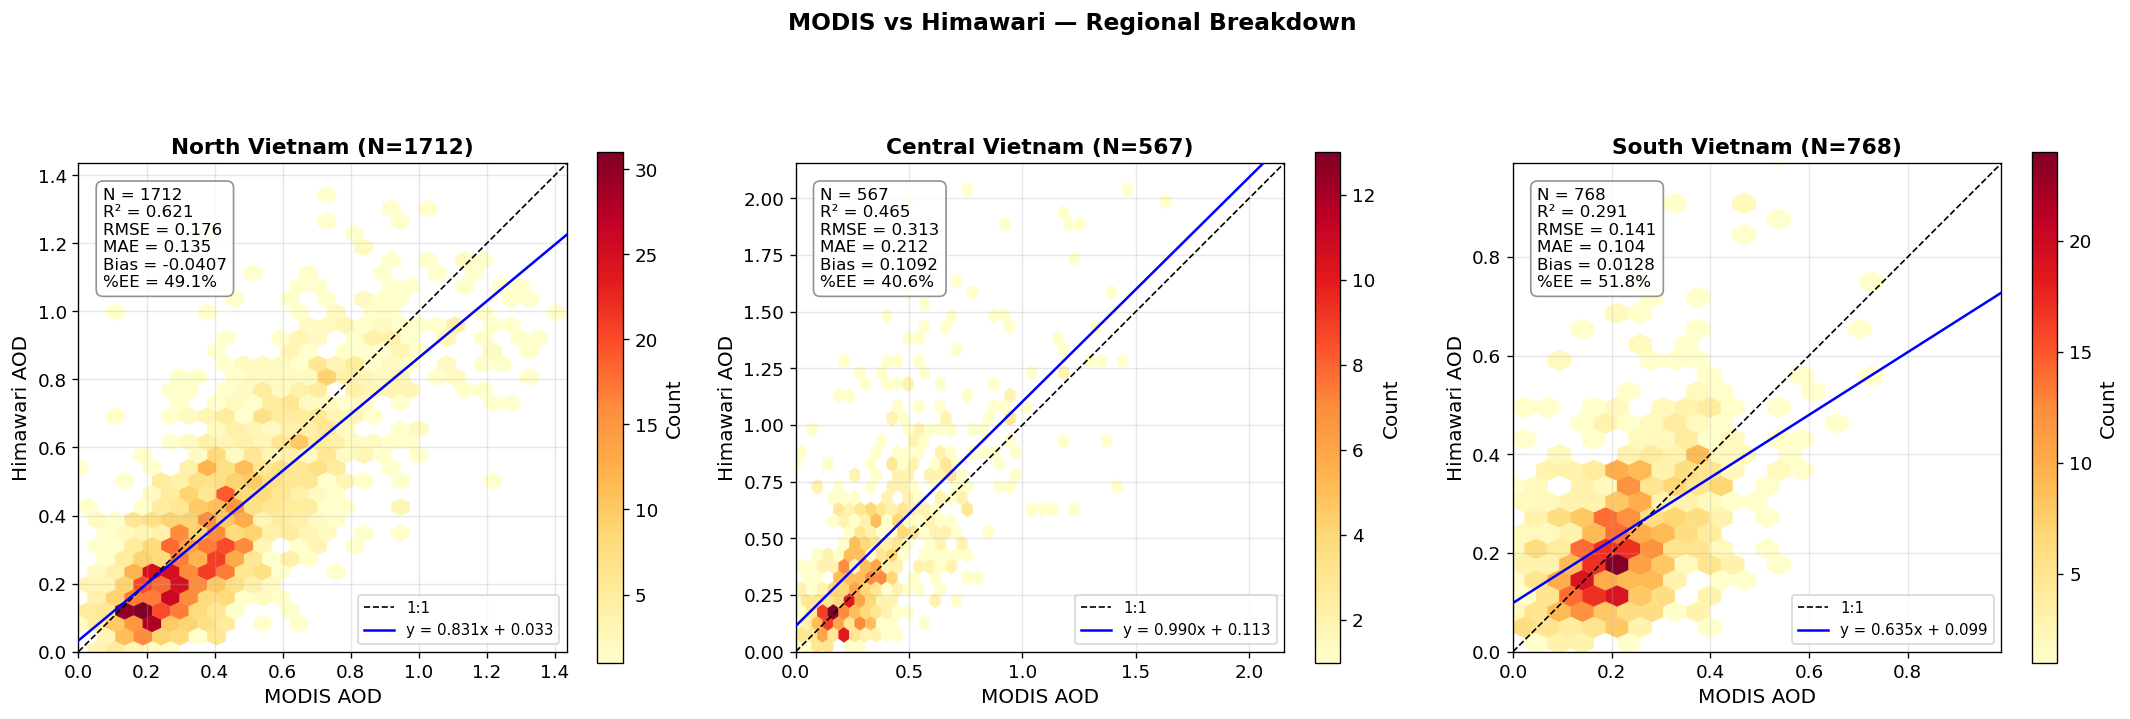


=== MODIS vs VIIRS by Region ===


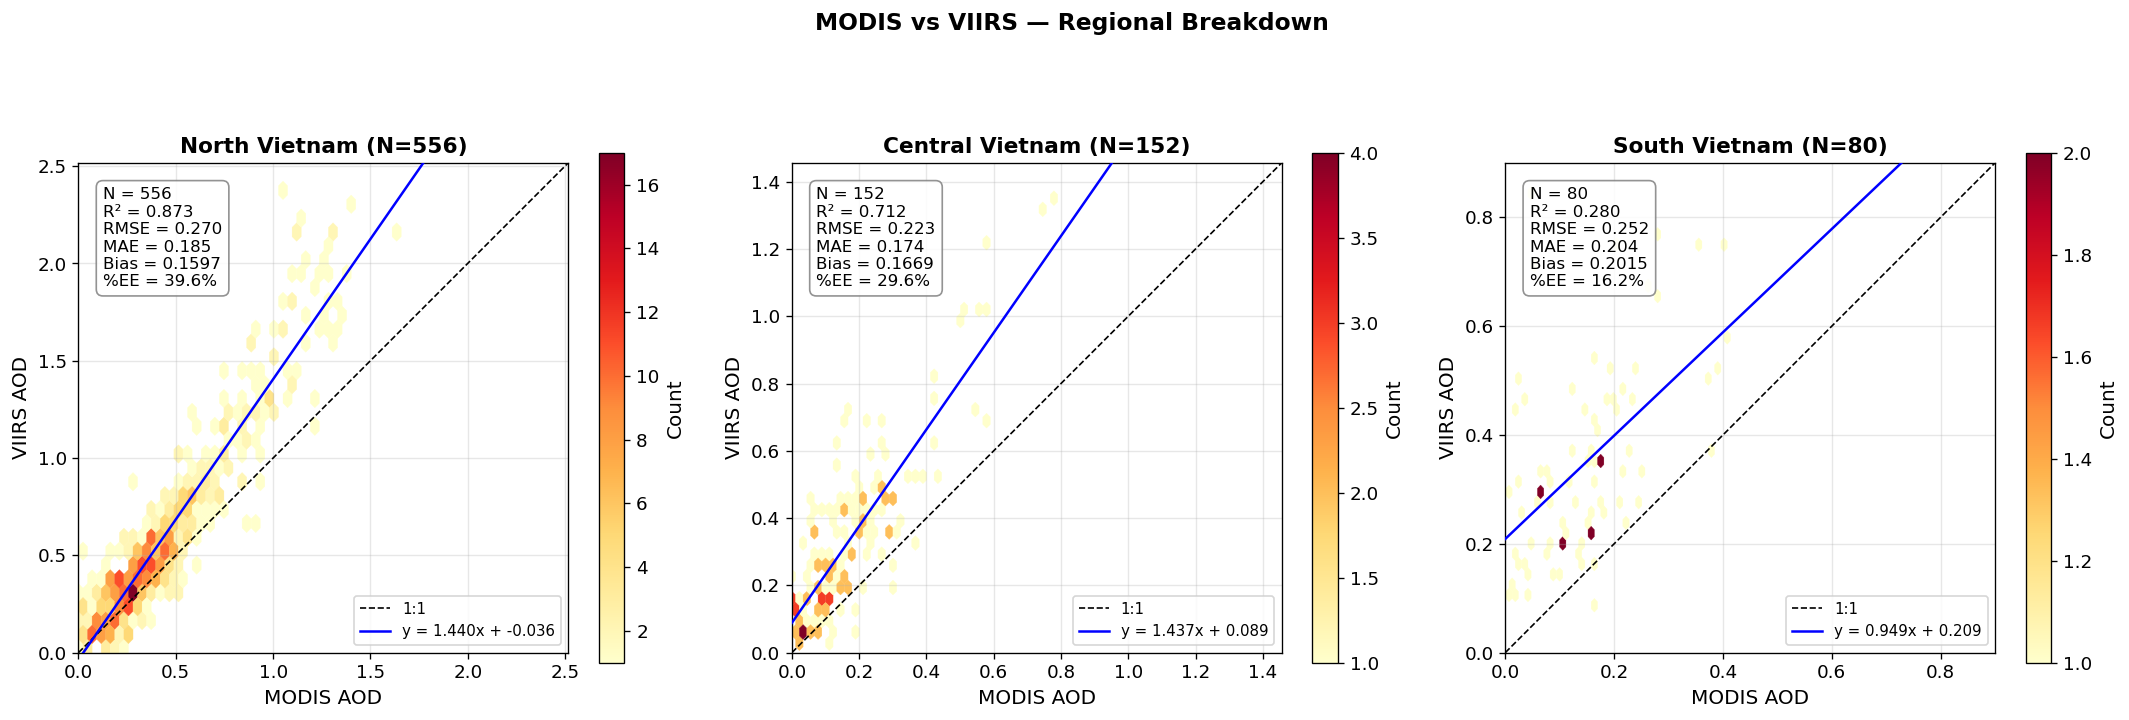


=== VIIRS vs Himawari by Region ===


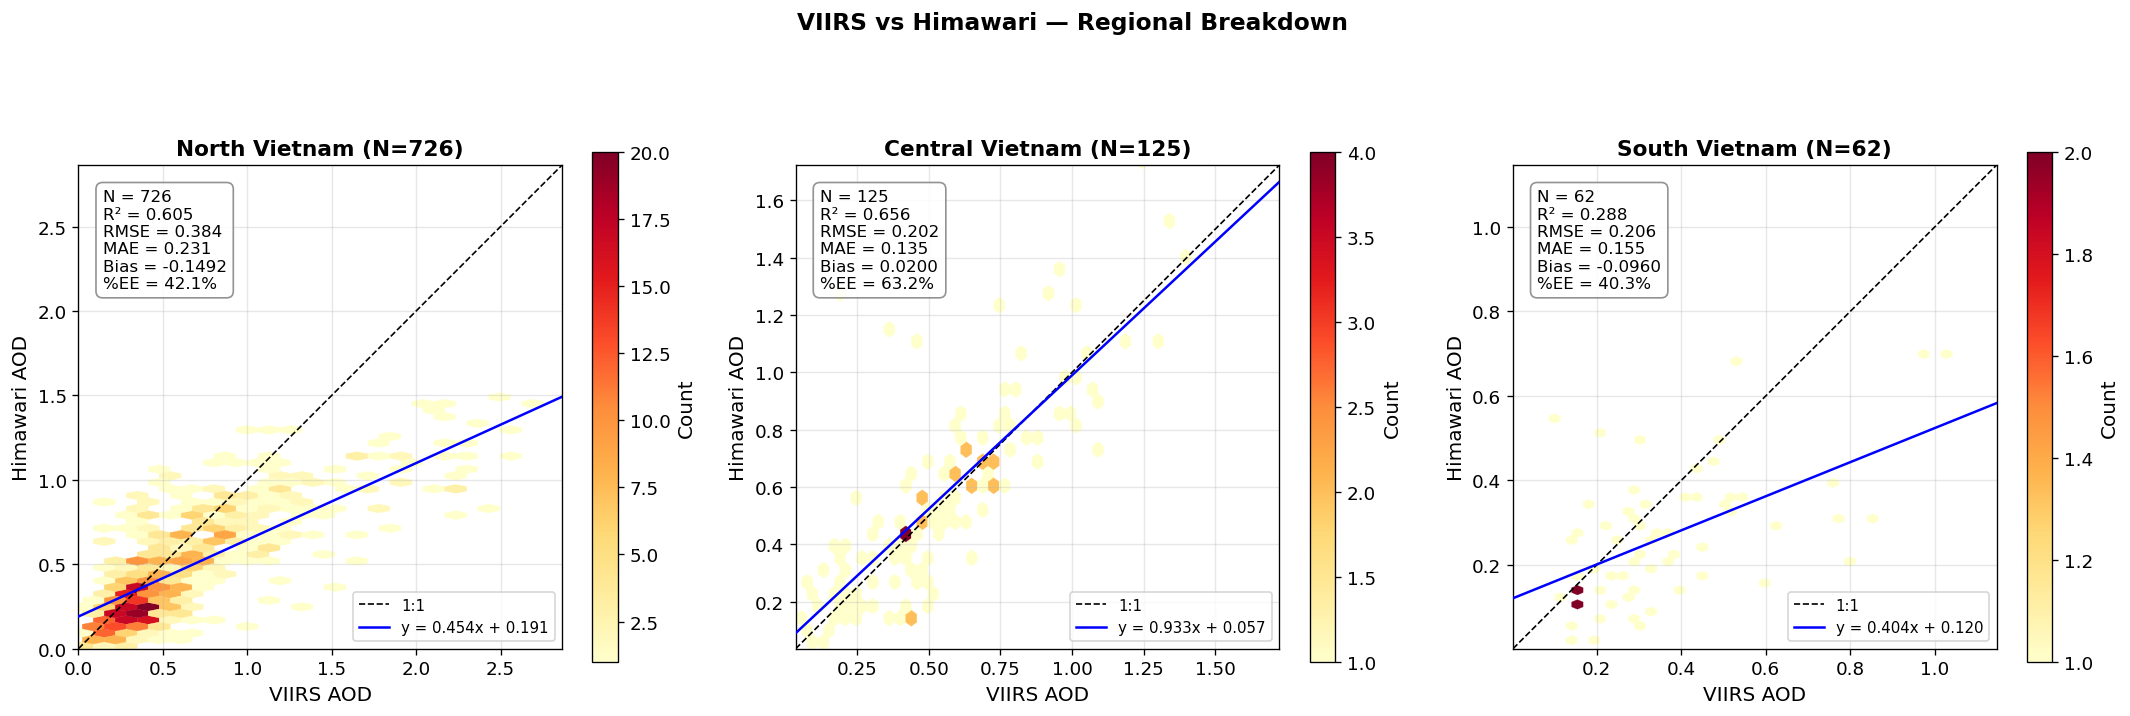

In [45]:
def regional_scatter_grid(pair_df, name_x, name_y):
    """3-panel scatter plot by region."""
    regions = ['North', 'Central', 'South']
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    results = {}

    for ax, reg in zip(axes, regions):
        sub = pair_df[pair_df['region'] == reg]
        col_x = f'AOD_{name_x}'
        col_y = f'AOD_{name_y}'
        if len(sub) < 5:
            ax.text(0.5, 0.5, f'{reg}\nInsufficient data', transform=ax.transAxes, ha='center')
            continue
        m = validation_scatter(sub[col_x], sub[col_y],
                              f'{name_x} AOD', f'{name_y} AOD',
                              f'{reg} Vietnam (N={len(sub)})', ax=ax)
        results[reg] = m

    fig.suptitle(f'{name_x} vs {name_y} — Regional Breakdown', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    return results

print('=== MODIS vs Himawari by Region ===')
reg_mh = regional_scatter_grid(pair_modis_hima, 'MODIS', 'Himawari')

print('\n=== MODIS vs VIIRS by Region ===')
reg_mv = regional_scatter_grid(pair_modis_viirs, 'MODIS', 'VIIRS')

print('\n=== VIIRS vs Himawari by Region ===')
reg_vh = regional_scatter_grid(pair_viirs_hima, 'VIIRS', 'Himawari')

In [46]:
rows = []
for pair_name, reg_dict in [('MODIS vs Himawari', reg_mh), ('MODIS vs VIIRS', reg_mv), ('VIIRS vs Himawari', reg_vh)]:
    for region, m in reg_dict.items():
        if m:
            rows.append({'Pair': pair_name, 'Region': region, **m})

df_regional = pd.DataFrame(rows)
print('Regional Summary:')
df_regional[['Pair', 'Region', 'N', 'R2', 'RMSE', 'MAE', 'Bias', '%EE']]

Regional Summary:


,Pair,Region,N,R2,RMSE,MAE,Bias,%EE
0,MODIS vs Himawari,North,1712,0.6209,0.1756,0.1352,-0.0407,49.1
1,MODIS vs Himawari,Central,567,0.4653,0.3132,0.2122,0.1092,40.6
2,MODIS vs Himawari,South,768,0.2908,0.1408,0.1040,0.0128,51.8
3,MODIS vs VIIRS,North,556,0.8731,0.2704,0.1846,0.1597,39.6
4,MODIS vs VIIRS,Central,152,0.7118,0.2226,0.1741,0.1669,29.6
5,MODIS vs VIIRS,South,80,0.2796,0.2515,0.2038,0.2015,16.2
6,VIIRS vs Himawari,North,726,0.6051,0.3839,0.2314,-0.1492,42.1
7,VIIRS vs Himawari,Central,125,0.6561,0.2018,0.1346,0.0200,63.2
8,VIIRS vs Himawari,South,62,0.2881,0.2056,0.1547,-0.0960,40.3


---
## 8. Seasonal Analysis

Analyze temporal patterns in satellite agreement. Vietnam has distinct seasonal aerosol regimes:
- **DJF** (Dec–Feb): Dry season in North, high AOD from biomass burning and continental transport
- **MAM** (Mar–May): Transition, high humidity begins in South
- **JJA** (Jun–Aug): Southwest monsoon, wet season, lower AOD, cloud contamination risk
- **SON** (Sep–Nov): Transition, biomass burning in Mekong

=== MODIS vs Himawari ===


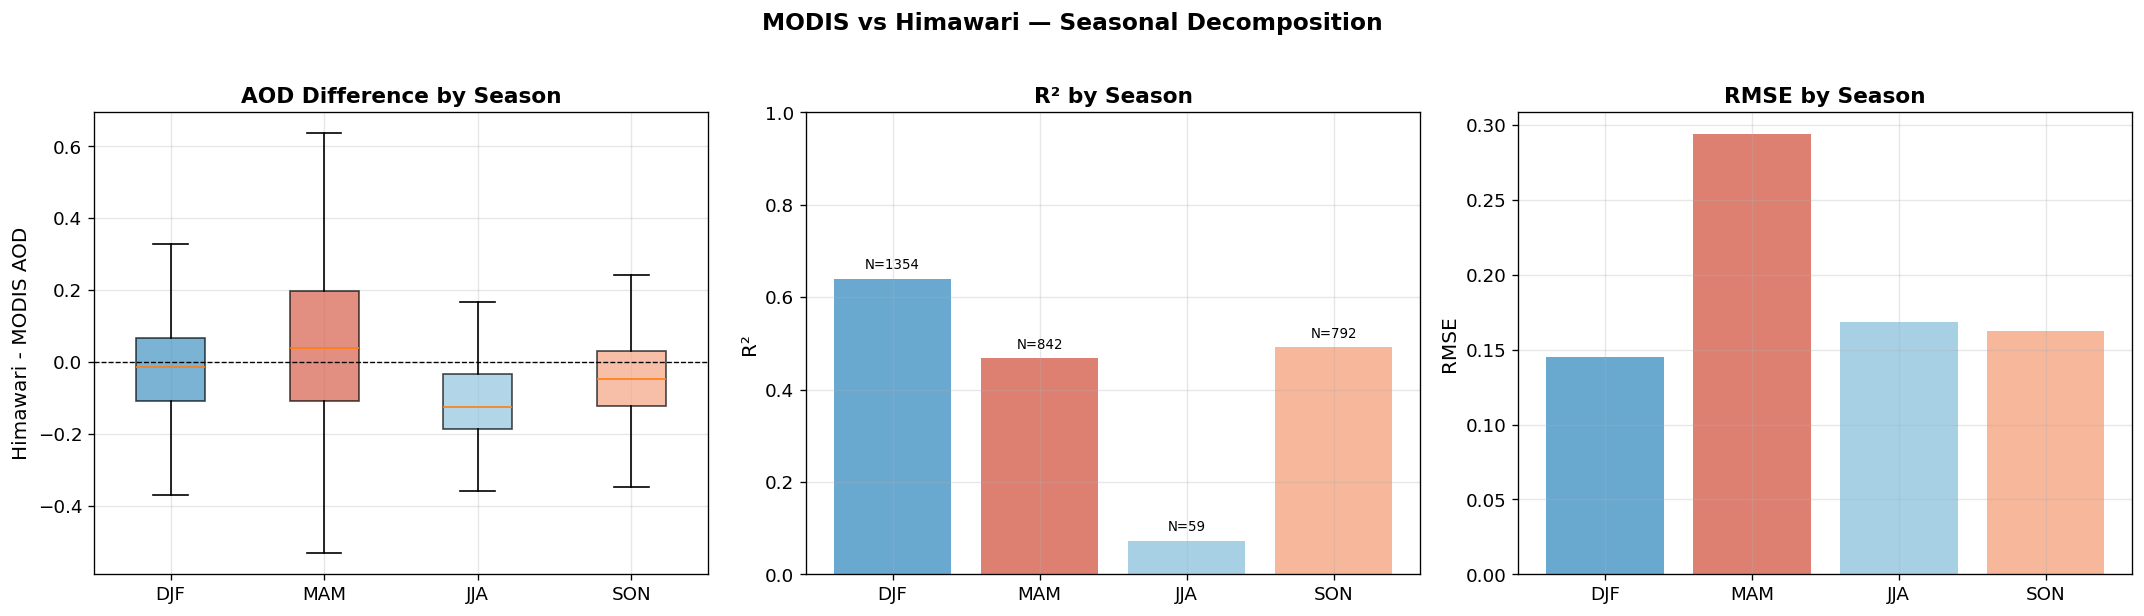

,Season,N,R,R2,RMSE,MAE,Bias,RelBias%,Slope,Intercept,%EE
0,DJF,1354,0.8002,0.6404,0.1449,0.1118,-0.0174,-4.72,0.9105,0.0155,54.1
1,MAM,842,0.6844,0.4684,0.2938,0.2109,0.0701,15.71,0.7842,0.1664,37.8
2,JJA,59,0.2705,0.0732,0.1688,0.1459,-0.1116,-41.07,0.2791,0.0843,25.4
3,SON,792,0.7019,0.4927,0.1624,0.1188,-0.0339,-10.07,0.7401,0.0537,50.9



=== MODIS vs VIIRS ===


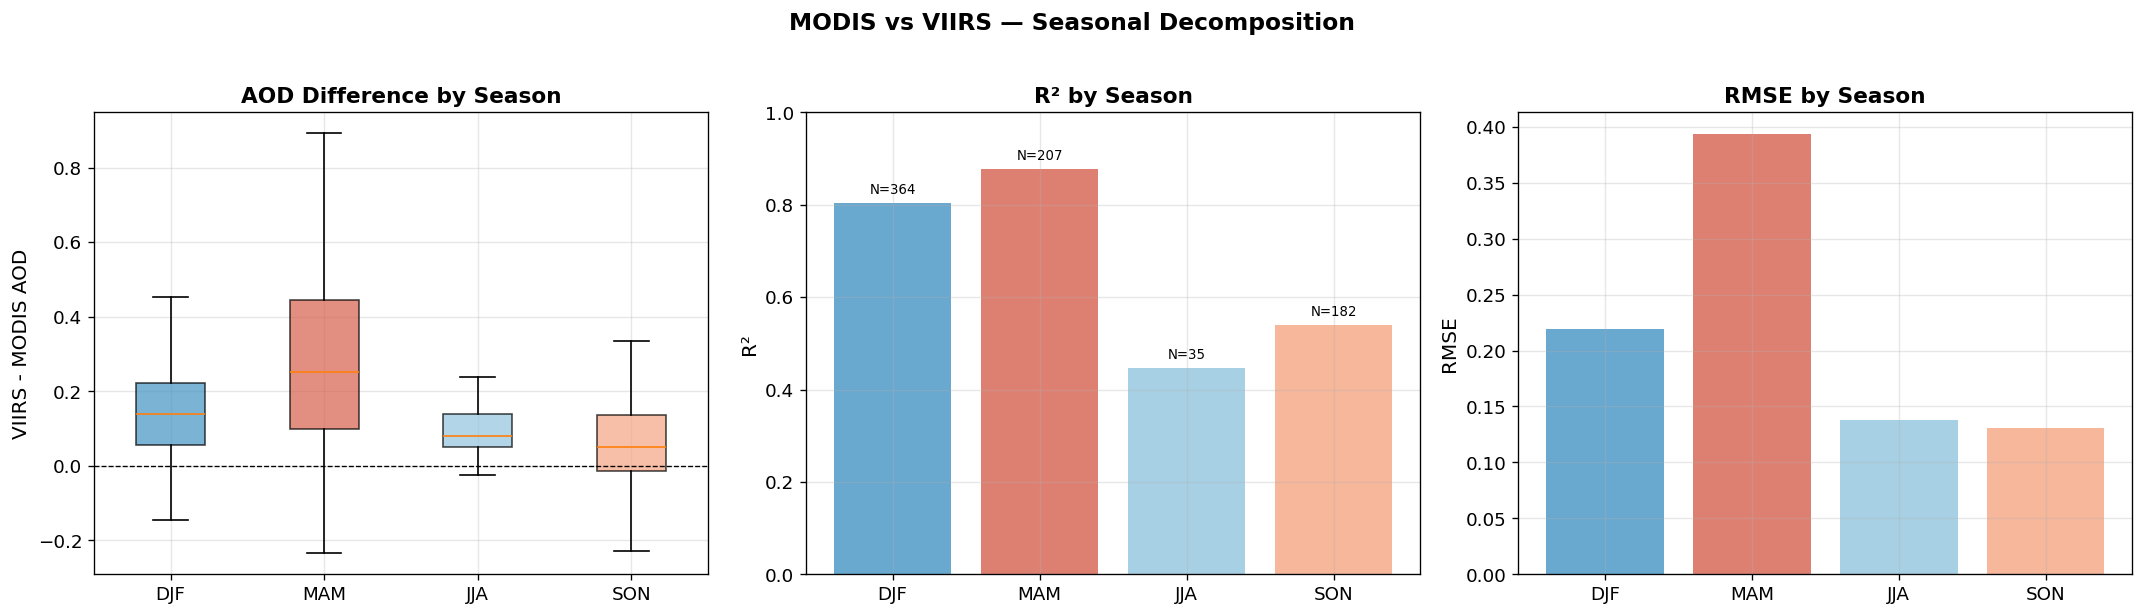

,Season,N,R,R2,RMSE,MAE,Bias,RelBias%,Slope,Intercept,%EE
0,DJF,364,0.8970,0.8046,0.2192,0.1650,0.1559,44.21,1.2009,0.0851,34.6
1,MAM,207,0.9369,0.8777,0.3931,0.3077,0.2864,56.61,1.3850,0.0916,18.4
2,JJA,35,0.6679,0.4461,0.1375,0.1073,0.1022,66.83,0.9030,0.1170,37.1
3,SON,182,0.7344,0.5393,0.1308,0.0982,0.0587,22.59,0.8828,0.0892,55.5



=== VIIRS vs Himawari ===


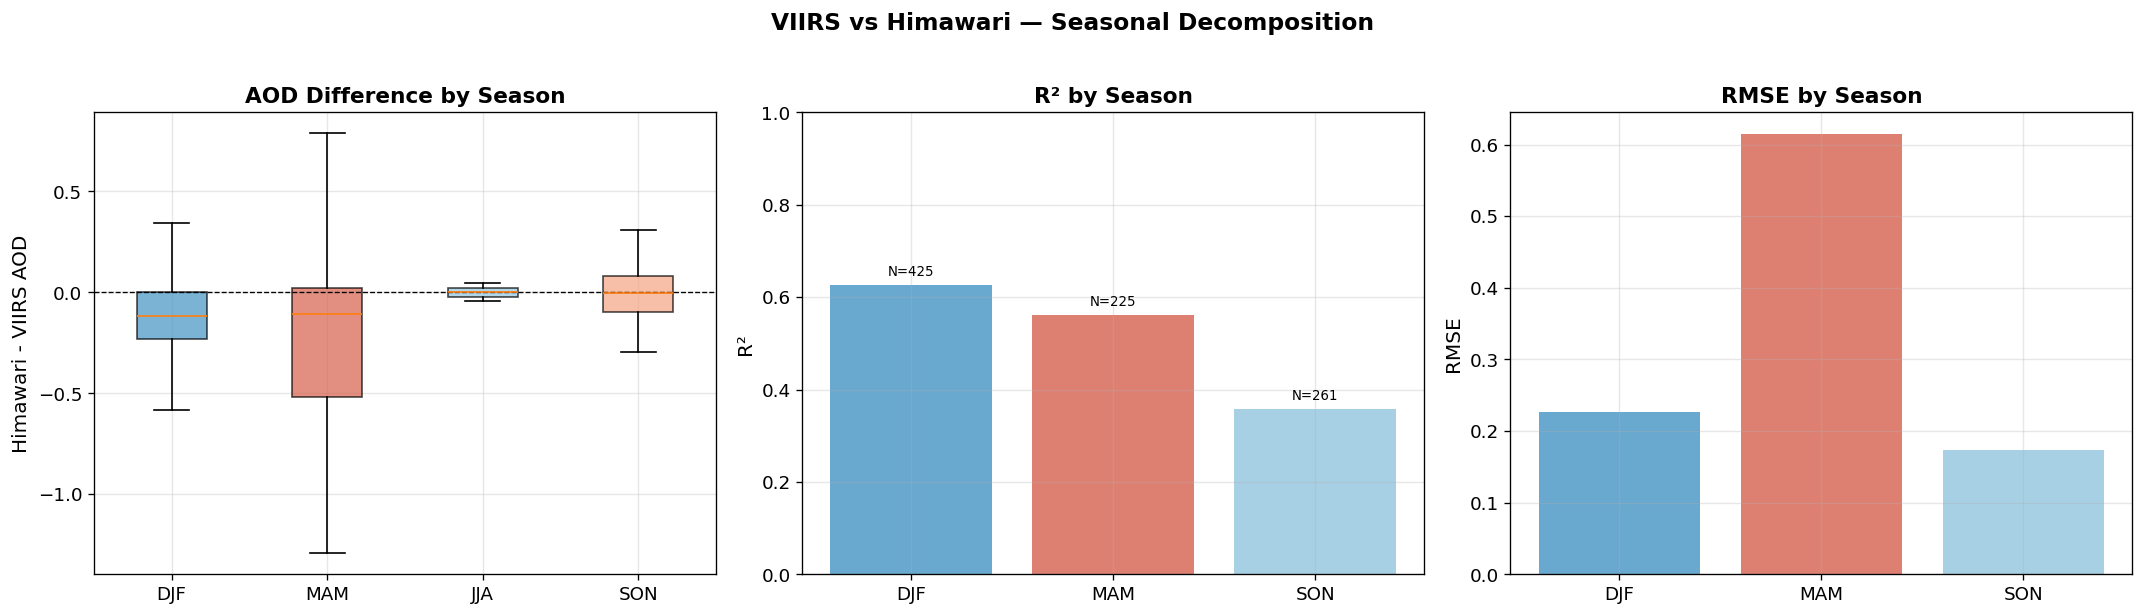

,Season,N,R,R2,RMSE,MAE,Bias,RelBias%,Slope,Intercept,%EE
0,DJF,425,0.7909,0.6255,0.2272,0.1741,-0.1160,-20.06,0.7201,0.0459,43.5
1,MAM,225,0.7497,0.5620,0.6142,0.3906,-0.2928,-30.70,0.3688,0.3091,39.1
2,SON,261,0.5983,0.3580,0.1739,0.1244,0.0130,4.09,0.8160,0.0713,51.7


In [47]:
def seasonal_analysis(pair_df, name_x, name_y):
    """Compute metrics by season and produce box plots."""
    col_x = f'AOD_{name_x}'
    col_y = f'AOD_{name_y}'
    pair_df = pair_df.copy()
    pair_df['month'] = pair_df['datetime'].dt.month
    pair_df['season'] = pair_df['month'].apply(get_season)
    pair_df['diff'] = pair_df[col_y] - pair_df[col_x]

    season_order = ['DJF', 'MAM', 'JJA', 'SON']
    season_metrics = {}
    for s in season_order:
        sub = pair_df[pair_df['season'] == s]
        m = compute_metrics(sub[col_x], sub[col_y])
        if m:
            season_metrics[s] = m

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Box plot of differences by season
    season_data = [pair_df[pair_df['season'] == s]['diff'].dropna() for s in season_order]
    bp = axes[0].boxplot(season_data, labels=season_order, patch_artist=True, showfliers=False)
    season_colors = ['#4393c3', '#d6604d', '#92c5de', '#f4a582']
    for patch, color in zip(bp['boxes'], season_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].axhline(0, color='k', ls='--', lw=0.8)
    axes[0].set_ylabel(f'{name_y} - {name_x} AOD')
    axes[0].set_title(f'AOD Difference by Season', fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # R2 and RMSE by season
    if season_metrics:
        seasons_with_data = [s for s in season_order if s in season_metrics]
        r2_vals = [season_metrics[s]['R2'] for s in seasons_with_data]
        rmse_vals = [season_metrics[s]['RMSE'] for s in seasons_with_data]
        n_vals = [season_metrics[s]['N'] for s in seasons_with_data]

        x_pos = range(len(seasons_with_data))
        axes[1].bar(x_pos, r2_vals, color=season_colors[:len(seasons_with_data)], alpha=0.8)
        axes[1].set_xticks(x_pos)
        axes[1].set_xticklabels(seasons_with_data)
        axes[1].set_ylabel('R\u00b2')
        axes[1].set_title('R\u00b2 by Season', fontweight='bold')
        axes[1].set_ylim(0, 1)
        axes[1].grid(True, alpha=0.3)
        for i, (r2, n) in enumerate(zip(r2_vals, n_vals)):
            axes[1].text(i, r2 + 0.02, f'N={n}', ha='center', fontsize=8)

        axes[2].bar(x_pos, rmse_vals, color=season_colors[:len(seasons_with_data)], alpha=0.8)
        axes[2].set_xticks(x_pos)
        axes[2].set_xticklabels(seasons_with_data)
        axes[2].set_ylabel('RMSE')
        axes[2].set_title('RMSE by Season', fontweight='bold')
        axes[2].grid(True, alpha=0.3)

    fig.suptitle(f'{name_x} vs {name_y} — Seasonal Decomposition', fontweight='bold', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame([{'Season': s, **m} for s, m in season_metrics.items()])

print('=== MODIS vs Himawari ===')
season_mh = seasonal_analysis(pair_modis_hima, 'MODIS', 'Himawari')
display(season_mh)

print('\n=== MODIS vs VIIRS ===')
season_mv = seasonal_analysis(pair_modis_viirs, 'MODIS', 'VIIRS')
display(season_mv)

print('\n=== VIIRS vs Himawari ===')
season_vh = seasonal_analysis(pair_viirs_hima, 'VIIRS', 'Himawari')
display(season_vh)

---
## 9. Monthly Time Series

Track AOD temporal evolution and inter-sensor differences over the study period.

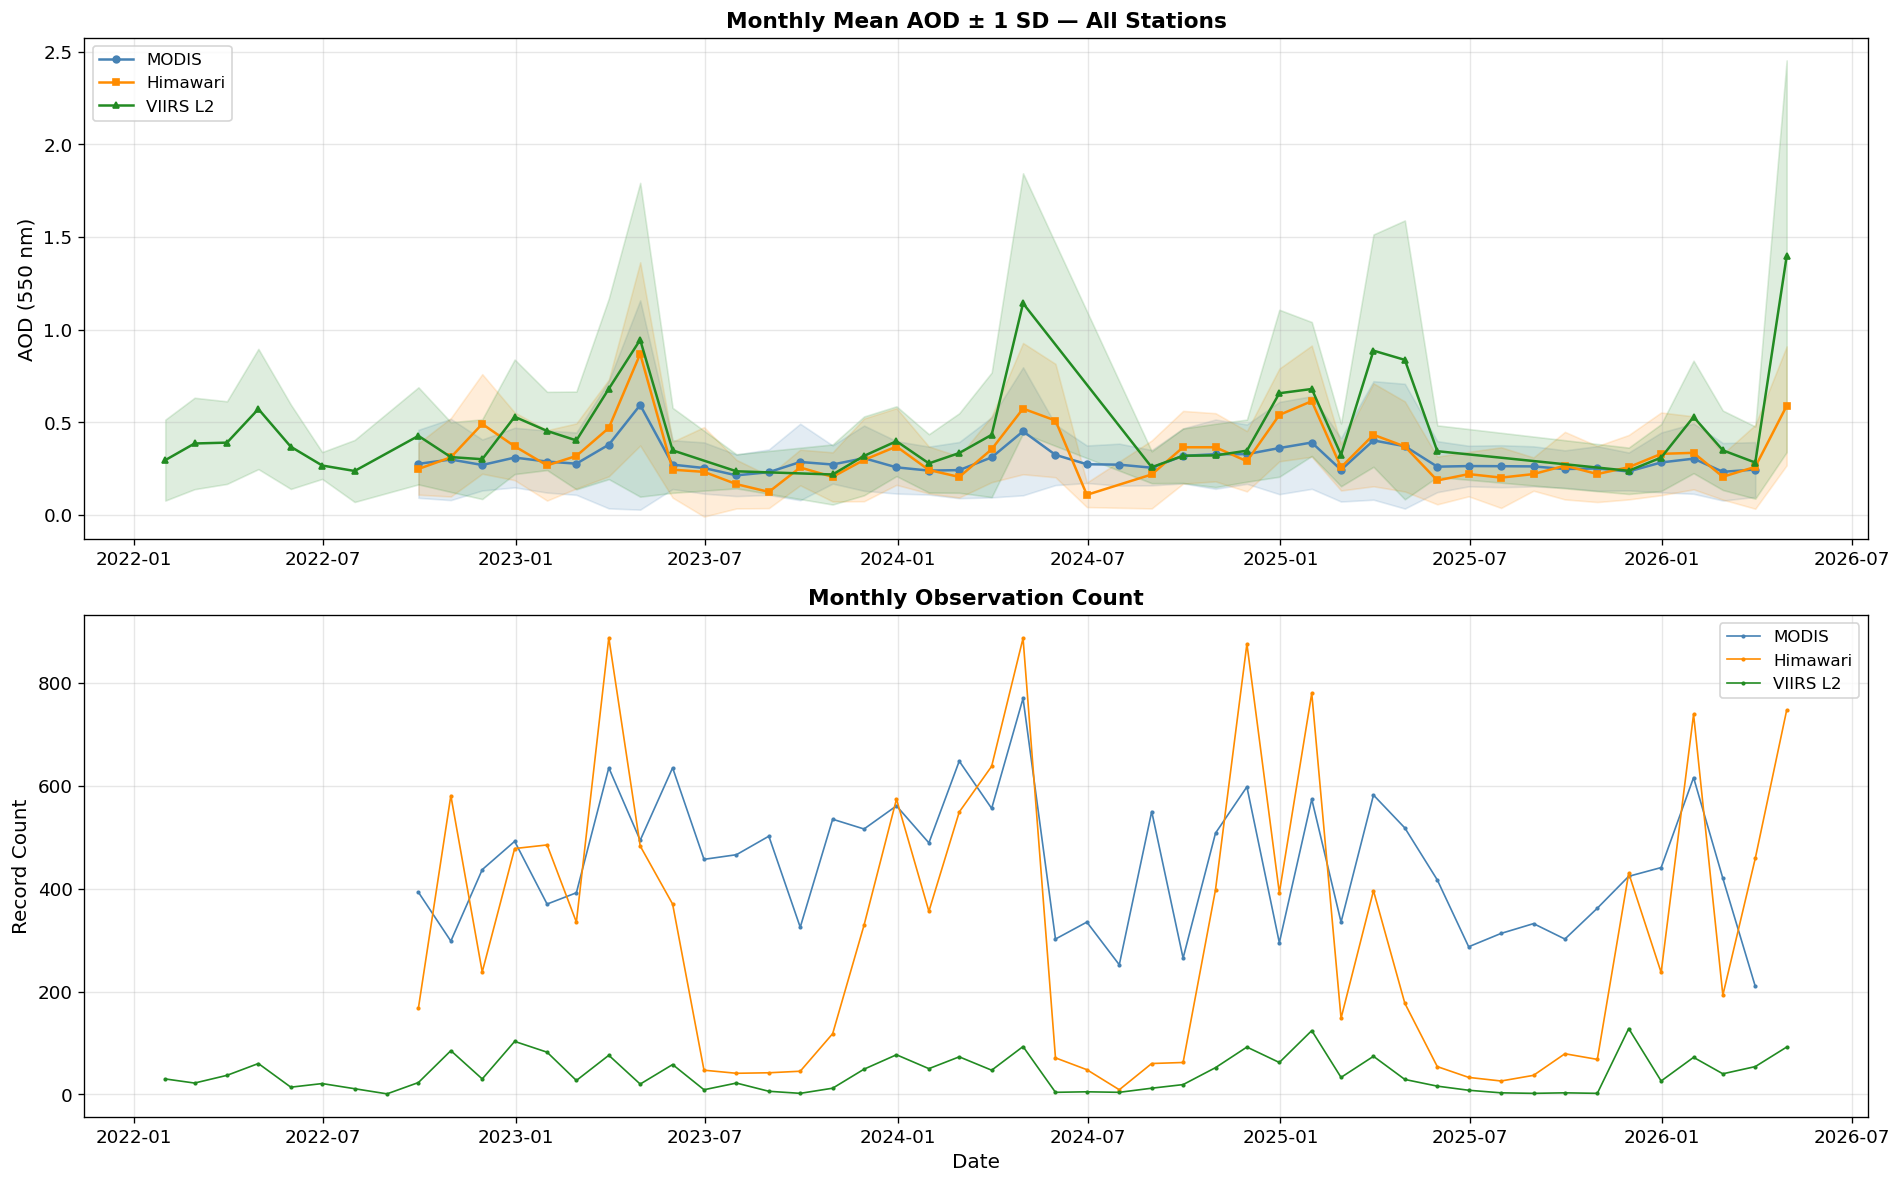

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Monthly mean AOD per sensor
for name, df, color, marker in [
    ('MODIS', modis, 'steelblue', 'o'),
    ('Himawari', hima, 'darkorange', 's'),
    ('VIIRS L2', viirs_l2, 'forestgreen', '^')
]:
    monthly = df.set_index('datetime').resample('M')['aod_550'].agg(['mean', 'std', 'count'])
    monthly = monthly[monthly['count'] >= 10]
    axes[0].plot(monthly.index, monthly['mean'], color=color, marker=marker, ms=4,
                 label=name, lw=1.5)
    axes[0].fill_between(monthly.index,
                          monthly['mean'] - monthly['std'],
                          monthly['mean'] + monthly['std'],
                          color=color, alpha=0.15)

axes[0].set_ylabel('AOD (550 nm)')
axes[0].set_title('Monthly Mean AOD ± 1 SD — All Stations', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Monthly record count per sensor
for name, df, color in [('MODIS', modis, 'steelblue'), ('Himawari', hima, 'darkorange'), ('VIIRS L2', viirs_l2, 'forestgreen')]:
    monthly_n = df.set_index('datetime').resample('M')['aod_550'].count()
    axes[1].plot(monthly_n.index, monthly_n.values, color=color, marker='.', ms=3, label=name, lw=1)

axes[1].set_ylabel('Record Count')
axes[1].set_xlabel('Date')
axes[1].set_title('Monthly Observation Count', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Sensitivity Analysis: Time Window

Evaluate how the collocation time tolerance affects agreement metrics. Tighter windows reduce representativeness error but also reduce sample size.

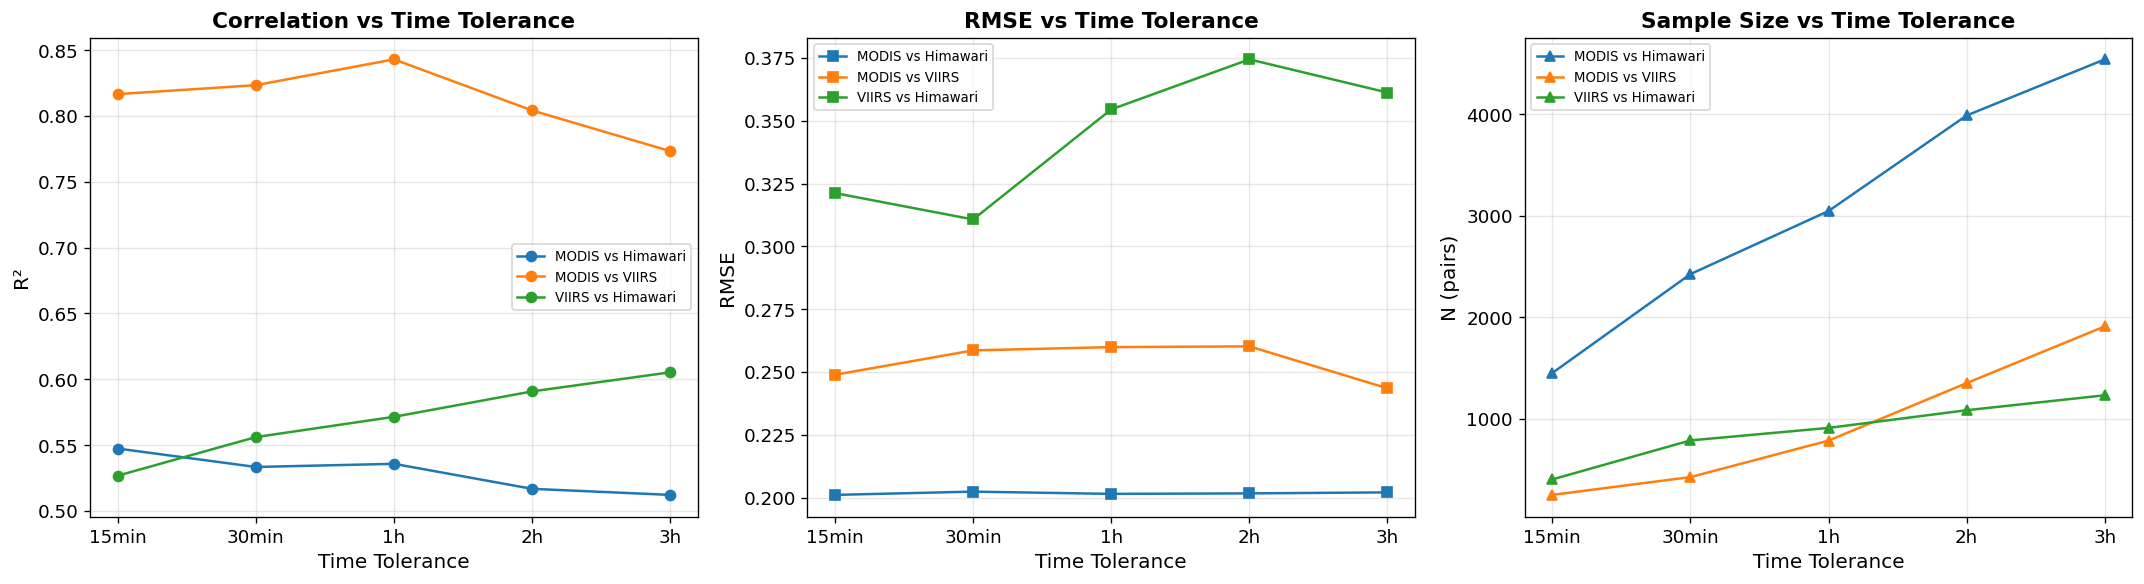

,Pair,Tolerance,N,R2,RMSE,Bias
0,MODIS vs Himawari,15min,1453,0.5474,0.2011,0.0023
1,MODIS vs VIIRS,15min,254,0.8166,0.2489,0.1494
2,VIIRS vs Himawari,15min,406,0.5268,0.3212,-0.1111
3,MODIS vs Himawari,30min,2426,0.5334,0.2024,0.0056
4,MODIS vs VIIRS,30min,429,0.8234,0.2586,0.1584
5,VIIRS vs Himawari,30min,790,0.5561,0.3107,-0.1028
6,MODIS vs Himawari,1h,3047,0.5358,0.2015,0.0007
7,MODIS vs VIIRS,1h,788,0.8430,0.2599,0.1654
8,VIIRS vs Himawari,1h,913,0.5715,0.3545,-0.1225
9,MODIS vs Himawari,2h,3987,0.5168,0.2017,-0.0067


In [49]:
tolerances = ['15min', '30min', '1h', '2h', '3h']
sens_results = []

for tol in tolerances:
    for name_ref, name_tgt, df_ref, df_tgt in [
        ('MODIS', 'Himawari', modis, hima),
        ('MODIS', 'VIIRS', modis, viirs_l2),
        ('VIIRS', 'Himawari', viirs_l2, hima),
    ]:
        d1 = df_ref[['station_name', 'datetime', 'aod_550']].dropna(subset=['aod_550']).copy()
        d2 = df_tgt[['station_name', 'datetime', 'aod_550']].dropna(subset=['aod_550']).copy()
        d1 = d1.rename(columns={'aod_550': 'aod_ref'})
        d2 = d2.rename(columns={'aod_550': 'aod_tgt'})

        # Per-station merge to avoid global sort requirement
        common = set(d1['station_name'].unique()) & set(d2['station_name'].unique())
        parts = []
        for stn in common:
            s1 = d1[d1['station_name'] == stn].sort_values('datetime').reset_index(drop=True)
            s2 = d2[d2['station_name'] == stn].sort_values('datetime').reset_index(drop=True)
            if len(s1) == 0 or len(s2) == 0:
                continue
            merged = pd.merge_asof(s1, s2[['datetime', 'aod_tgt']],
                                    on='datetime', tolerance=pd.Timedelta(tol), direction='nearest')
            merged = merged.dropna(subset=['aod_tgt'])
            if len(merged) > 0:
                parts.append(merged)

        if not parts:
            continue
        merged_all = pd.concat(parts, ignore_index=True)
        m = compute_metrics(merged_all['aod_ref'], merged_all['aod_tgt'])
        if m:
            m['Tolerance'] = tol
            m['Pair'] = f'{name_ref} vs {name_tgt}'
            sens_results.append(m)

df_sens = pd.DataFrame(sens_results)

# Plot sensitivity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = df_sens['Pair'].unique()
for pair in pairs:
    sub = df_sens[df_sens['Pair'] == pair]
    axes[0].plot(range(len(sub)), sub['R2'], marker='o', label=pair)
    axes[1].plot(range(len(sub)), sub['RMSE'], marker='s', label=pair)
    axes[2].plot(range(len(sub)), sub['N'], marker='^', label=pair)

for ax, ylabel, title in zip(axes, ['R²', 'RMSE', 'N (pairs)'],
                                    ['Correlation', 'RMSE', 'Sample Size']):
    ax.set_xticks(range(len(tolerances)))
    ax.set_xticklabels(tolerances)
    ax.set_xlabel('Time Tolerance')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} vs Time Tolerance', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df_sens[['Pair', 'Tolerance', 'N', 'R2', 'RMSE', 'Bias']]

---
## 11. Comprehensive Summary

In [50]:
all_global = []
for pair_name, m in [('MODIS vs Himawari', m_global),
                      ('MODIS vs VIIRS', m_global_mv),
                      ('VIIRS vs Himawari', m_global_vh)]:
    if m:
        all_global.append({'Pair': pair_name, **m})

df_summary = pd.DataFrame(all_global)
print('=== Global Pairwise Summary ===')
print(f'Collocation tolerance: {TIME_TOLERANCE}')
print()
df_summary

=== Global Pairwise Summary ===
Collocation tolerance: 1h



,Pair,N,R,R2,RMSE,MAE,Bias,RelBias%,Slope,Intercept,%EE
0,MODIS vs Himawari,3047,0.7320,0.5358,0.2015,0.1417,0.0007,0.18,0.8535,0.0563,48.2
1,MODIS vs VIIRS,788,0.9181,0.8430,0.2599,0.1845,0.1654,45.60,1.3428,0.0410,35.3
2,VIIRS vs Himawari,913,0.7560,0.5715,0.3545,0.2130,-0.1225,-20.58,0.4792,0.1875,44.9


---
## 12. Discussion & Conclusions

### Key Findings

1. **MODIS vs Himawari:** Moderate agreement overall. The Ångström exponent-based wavelength correction from 500→550 nm has limited impact because AE is unavailable for ~85% of Himawari records. Central Vietnam shows the weakest agreement, potentially due to complex aerosol types from biomass burning and terrain effects on the retrieval.

2. **MODIS vs VIIRS:** Expected to show the best agreement since both are polar-orbiting, sun-synchronous sensors with similar overpass times (Aqua and NOAA-20 ~13:30 LT) and native 550 nm retrieval. Sample size depends on temporal overlap of cloud-free observations.

3. **VIIRS vs Himawari:** Similar patterns to MODIS vs Himawari, with the same wavelength correction limitation.

### Limitations
- **Wavelength correction:** Himawari AE availability is low; the uncorrected 500 nm fallback introduces systematic differences
- **Spatial collocation:** Satellite data was extracted at station locations with different pixel sizes (MODIS ~1 km, Himawari ~5 km, VIIRS ~750 m at nadir), which introduces spatial representativeness differences
- **Temporal sampling:** Polar-orbiting sensors (MODIS, VIIRS) provide 1–2 observations/day vs hourly for Himawari; the ±1h window may capture Himawari at different atmospheric conditions
- **QA filtering:** Different quality assurance schemes across sensors may introduce sampling biases

### Recommendations for Future Work
- Expand VIIRS L2 dataset (currently limited to NOAA-20; add SNPP for longer record)
- Investigate cloud screening differences between sensors
- Apply aerosol-type-dependent corrections for Central Vietnam
- Compare L2 (swath) vs L3 (gridded) products to quantify aggregation effects